In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Image size and batch size
img_size = 224
batch_size = 32

# Data preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "C:\\Users\\thoma\\Desktop\\DL\\Case Study 3\\Training",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "C:\\Users\\thoma\\Desktop\\DL\\Case Study 3\\Training",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# CNN Model
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))

# Output layer
model.add(layers.Dense(4, activation='softmax'))
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Evaluate model
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.


c:\Users\thoma\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.7165 - loss: 0.7016 - val_accuracy: 0.8188 - val_loss: 0.5320
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 97s 694ms/step - accuracy: 0.8891 - loss: 0.3186 - val_accuracy: 0.8893 - val_loss: 0.3175
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 90s 640ms/step - accuracy: 0.9277 - loss: 0.2038 - val_accuracy: 0.8893 - val_loss: 0.3260
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 91s 651ms/step - accuracy: 0.9585 - loss: 0.1181 - val_accuracy: 0.8973 - val_loss: 0.3274
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 90s 645ms/step - accuracy: 0.9741 - loss: 0.0715 - val_accuracy: 0.9277 - val_loss: 0.2417
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 90s 639ms/step - accuracy: 0.9830 - loss: 0.0503 - val_accuracy: 0.8973 - val_loss: 0.3663
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 95s 666ms/step - accuracy: 0.9913 - loss: 0.0298 - val_accuracy: 0.9134 - val_loss: 0.3565
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 94s 672ms/step - accuracy: 0.9891 - loss: 0.0

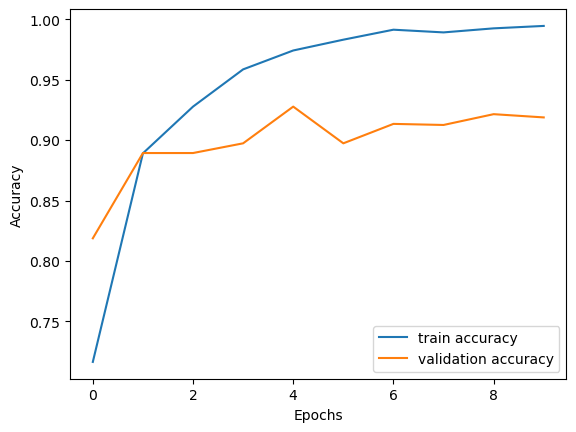

In [2]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()